# Lensed AGN Population with Multi-Survey Variability
This notebook simulates a lensed quasar population using `slsim`, showcasing rendering 
and microlensing extraction across LSST, Roman, and Euclid observatories.

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import vstack

import speclite.filters
import slsim
from slsim.Sources.SourcePopulation.point_plus_extended_sources import (
    PointPlusExtendedSources,
)
import slsim.Pipelines as pipelines
from slsim.Deflectors.DeflectorPopulation.galaxy_deflectors import GalaxyDeflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
from slsim.ImageSimulation.image_simulation import (
    simulate_image,
    rgb_image_from_image_list,
)

from slsim.Util.astro_util import theta_star_physical

from slsim.Pipelines import roman_speclite
from slsim.ImageSimulation.image_quality_lenstronomy import (
    ROMAN_BAND_LIST,
    LSST_BAND_LIST,
    EUCLID_BAND_LIST,
)

%load_ext autoreload
%autoreload 2

## 1. Filter Setup

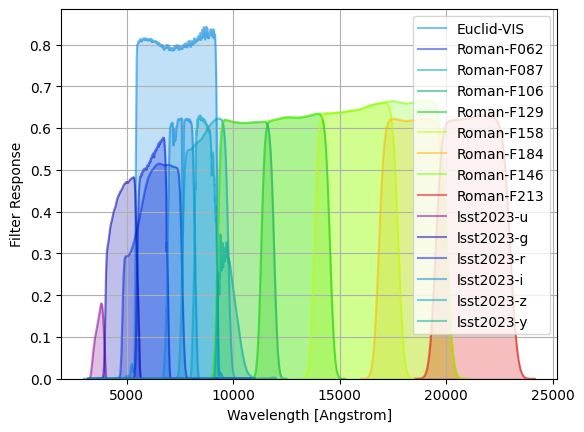

In [2]:
roman_speclite.configure_roman_filters()

filters = speclite.filters.load_filters(
    "Euclid-VIS",
    "Roman-F062",
    "Roman-F087",
    "Roman-F106",
    "Roman-F129",
    "Roman-F158",
    "Roman-F184",
    "Roman-F146",
    "Roman-F213",
    "lsst2023-u",
    "lsst2023-g",
    "lsst2023-r",
    "lsst2023-i",
    "lsst2023-z",
    "lsst2023-y",
)

# visualize the filters
speclite.filters.plot_filters(filters)

## 2. Population Setup (SkyPy Pipeline & QuasarRate)

In [3]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area_galaxies = Quantity(value=1, unit="deg2")
sky_area_qso = Quantity(value=1, unit="deg2")

# Using a standard path for Euclid/Roman/LSST defaults
path = os.path.dirname(slsim.__file__)
skypy_config_path = os.path.join(
    os.path.split(path)[0], "data/SkyPy/euclid-roman-lsst-like.yml"
)

galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config_path,
    sky_area=sky_area_galaxies,
    filters=None,
    cosmo=cosmo,
    z_min=0.0,
    z_max=3.0,
)

host_galaxy_candidates = vstack(
    [galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies],
    join_type="exact",
)

lens_galaxies = GalaxyDeflectors(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut={"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=sky_area_galaxies,
)

all_qsogen_bands = LSST_BAND_LIST + ROMAN_BAND_LIST + EUCLID_BAND_LIST

print("Generating quasar catalog...")
quasar_class = QuasarRate(
    skypy_config=skypy_config_path,
    cosmo=cosmo,
    sky_area=sky_area_qso,
    noise=True,
    redshifts=np.linspace(0.001, 3.01, 100),
    host_galaxy_candidate=host_galaxy_candidates,
    use_qsogen_sed=True,
    qsogen_bands=all_qsogen_bands,
    use_sed_interpolator=True,
)
quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)

source_quasar = PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source,
    cosmo=cosmo,
    sky_area=sky_area_qso,
    kwargs_cut={"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 5.0},
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    joint_point_source_kwargs={
        "variability_model": "light_curve",
        "kwargs_variability": set(all_qsogen_bands),
        "agn_driving_variability_model": "bending_power_law",
        "agn_driving_kwargs_variability": {
            "length_of_light_curve": 35000,
            "time_resolution": 1, 
            "log_breakpoint_frequency": 1 / 20,
            "low_frequency_slope": 1,
            "high_frequency_slope": 3,
            "standard_deviation": 0.9,
        },
        "lightcurve_time": np.linspace(-5000, 30000, 35000),
        "corona_height": 10,
        "r_resolution": 500,
    },
)

Generating quasar catalog...


/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/qsogen/qsosed.py:67: RuntimeWarning: overflow encountered in exp
  return (wav ** (-3)) / (np.exp(1.43877735e8 / (tbb * wav)) - 1.0)
Matching quasars with host galaxies:  29%|██▉       | 2500/8520 [00:00<00:01, 5006.14it/s]/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:123: RuntimeWarning: divide by zero encountered in log10
  M_bol = M_bol_sun - 2.5 * np.log10(L_bol)  # L_sun
/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:244: RuntimeWarning: divide by zero encountered in log10
  matched_bh_mass_exponents.append(np.log10(bh_masses[closest_local_index]))
Matching quasars with host galaxies: 100%|██████████| 8520/8520 [00:01<00:00, 5007.98it/s]


## 3. Lens Selection & Static Image Simulation
We draw the population and pick an ideal Quad lens for visualization across the observatories.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


LENS SYSTEM: z_s=2.4779 | z_l=1.0144 | R_E=1.2666 arcsec


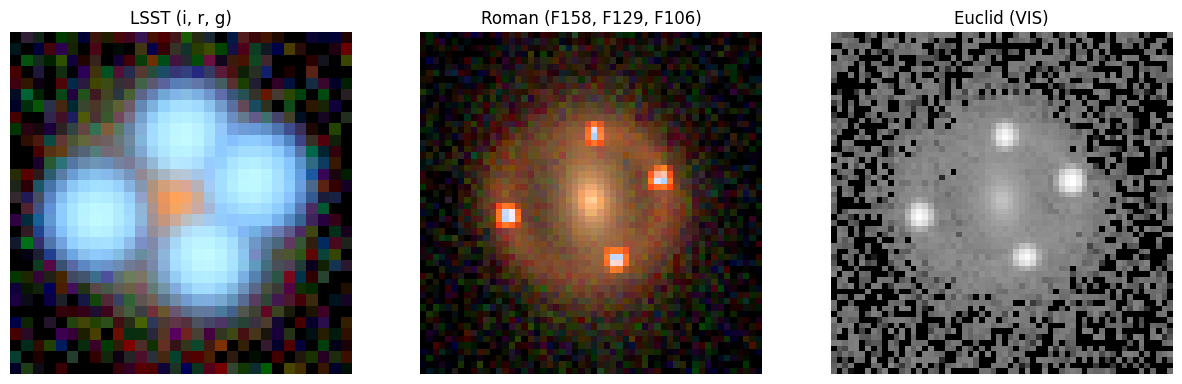

In [4]:
quasar_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=sky_area_qso * 500,
)
selected_lenses = quasar_lens_pop.draw_population(
    kwargs_lens_cuts={
        "min_image_separation": 1,
        "max_image_separation": 10,
        "second_brightest_image_cut": {"i": 26},
    },
    speed_factor=10000,
)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]
lens_class = quad_lenses[np.argmax([lens.einstein_radius[0] for lens in quad_lenses])]

print("=" * 50)
print(
    f"LENS SYSTEM: z_s={lens_class.source_redshift_list[0]:.4f} | z_l={lens_class.deflector_redshift:.4f} | R_E={lens_class.einstein_radius[0]:.4f} arcsec"
)
print("=" * 50)

# Simulate RGB Composites
FOV = 6  # arcsec
lsst_images = [
    simulate_image(
        lens_class,
        band=b,
        observatory="LSST",
        num_pix=int(FOV / 0.2),
        microlensing=True,
    )
    for b in ["i", "r", "g"]
]
roman_images = [
    simulate_image(
        lens_class,
        band=b,
        observatory="Roman",
        num_pix=int(FOV / 0.11),
        microlensing=True,
    )
    for b in ["F158", "F129", "F106"]
]
euclid_img = simulate_image(
    lens_class,
    band="VIS",
    observatory="Euclid",
    num_pix=int(FOV / 0.1),
    microlensing=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_image_from_image_list(lsst_images, stretch=0.5), origin="lower")
axes[0].set_title("LSST (i, r, g)")
axes[1].imshow(rgb_image_from_image_list(roman_images, stretch=0.5), origin="lower")
axes[1].set_title("Roman (F158, F129, F106)")
axes[2].imshow(np.log10(np.clip(euclid_img, 1e-5, None)), origin="lower", cmap="gray")
axes[2].set_title("Euclid (VIS)")
for ax in axes:
    ax.axis("off")
plt.show()

In [5]:
with open("lens_agn.pkl", "wb") as f:
    pickle.dump(lens_class, f)
print(
    f"Lens pickled — deflector z={lens_class.deflector_redshift:.4f}, "
    f"source z={lens_class.source_redshift_list[0]:.4f}"
)

Lens pickled — deflector z=1.0144, source z=2.4779


## 4. Visualize Lightcurves with Microlensing
We extract 10-year microlensing lightcurves across the observatories, showcasing isolated residuals.


Processing Multi-Band Macrolensing and Microlensing...


/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_

Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.


/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/global/u1/s/sharma/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Visualizing Continuous Macrolensing + Microlensing Signatures...


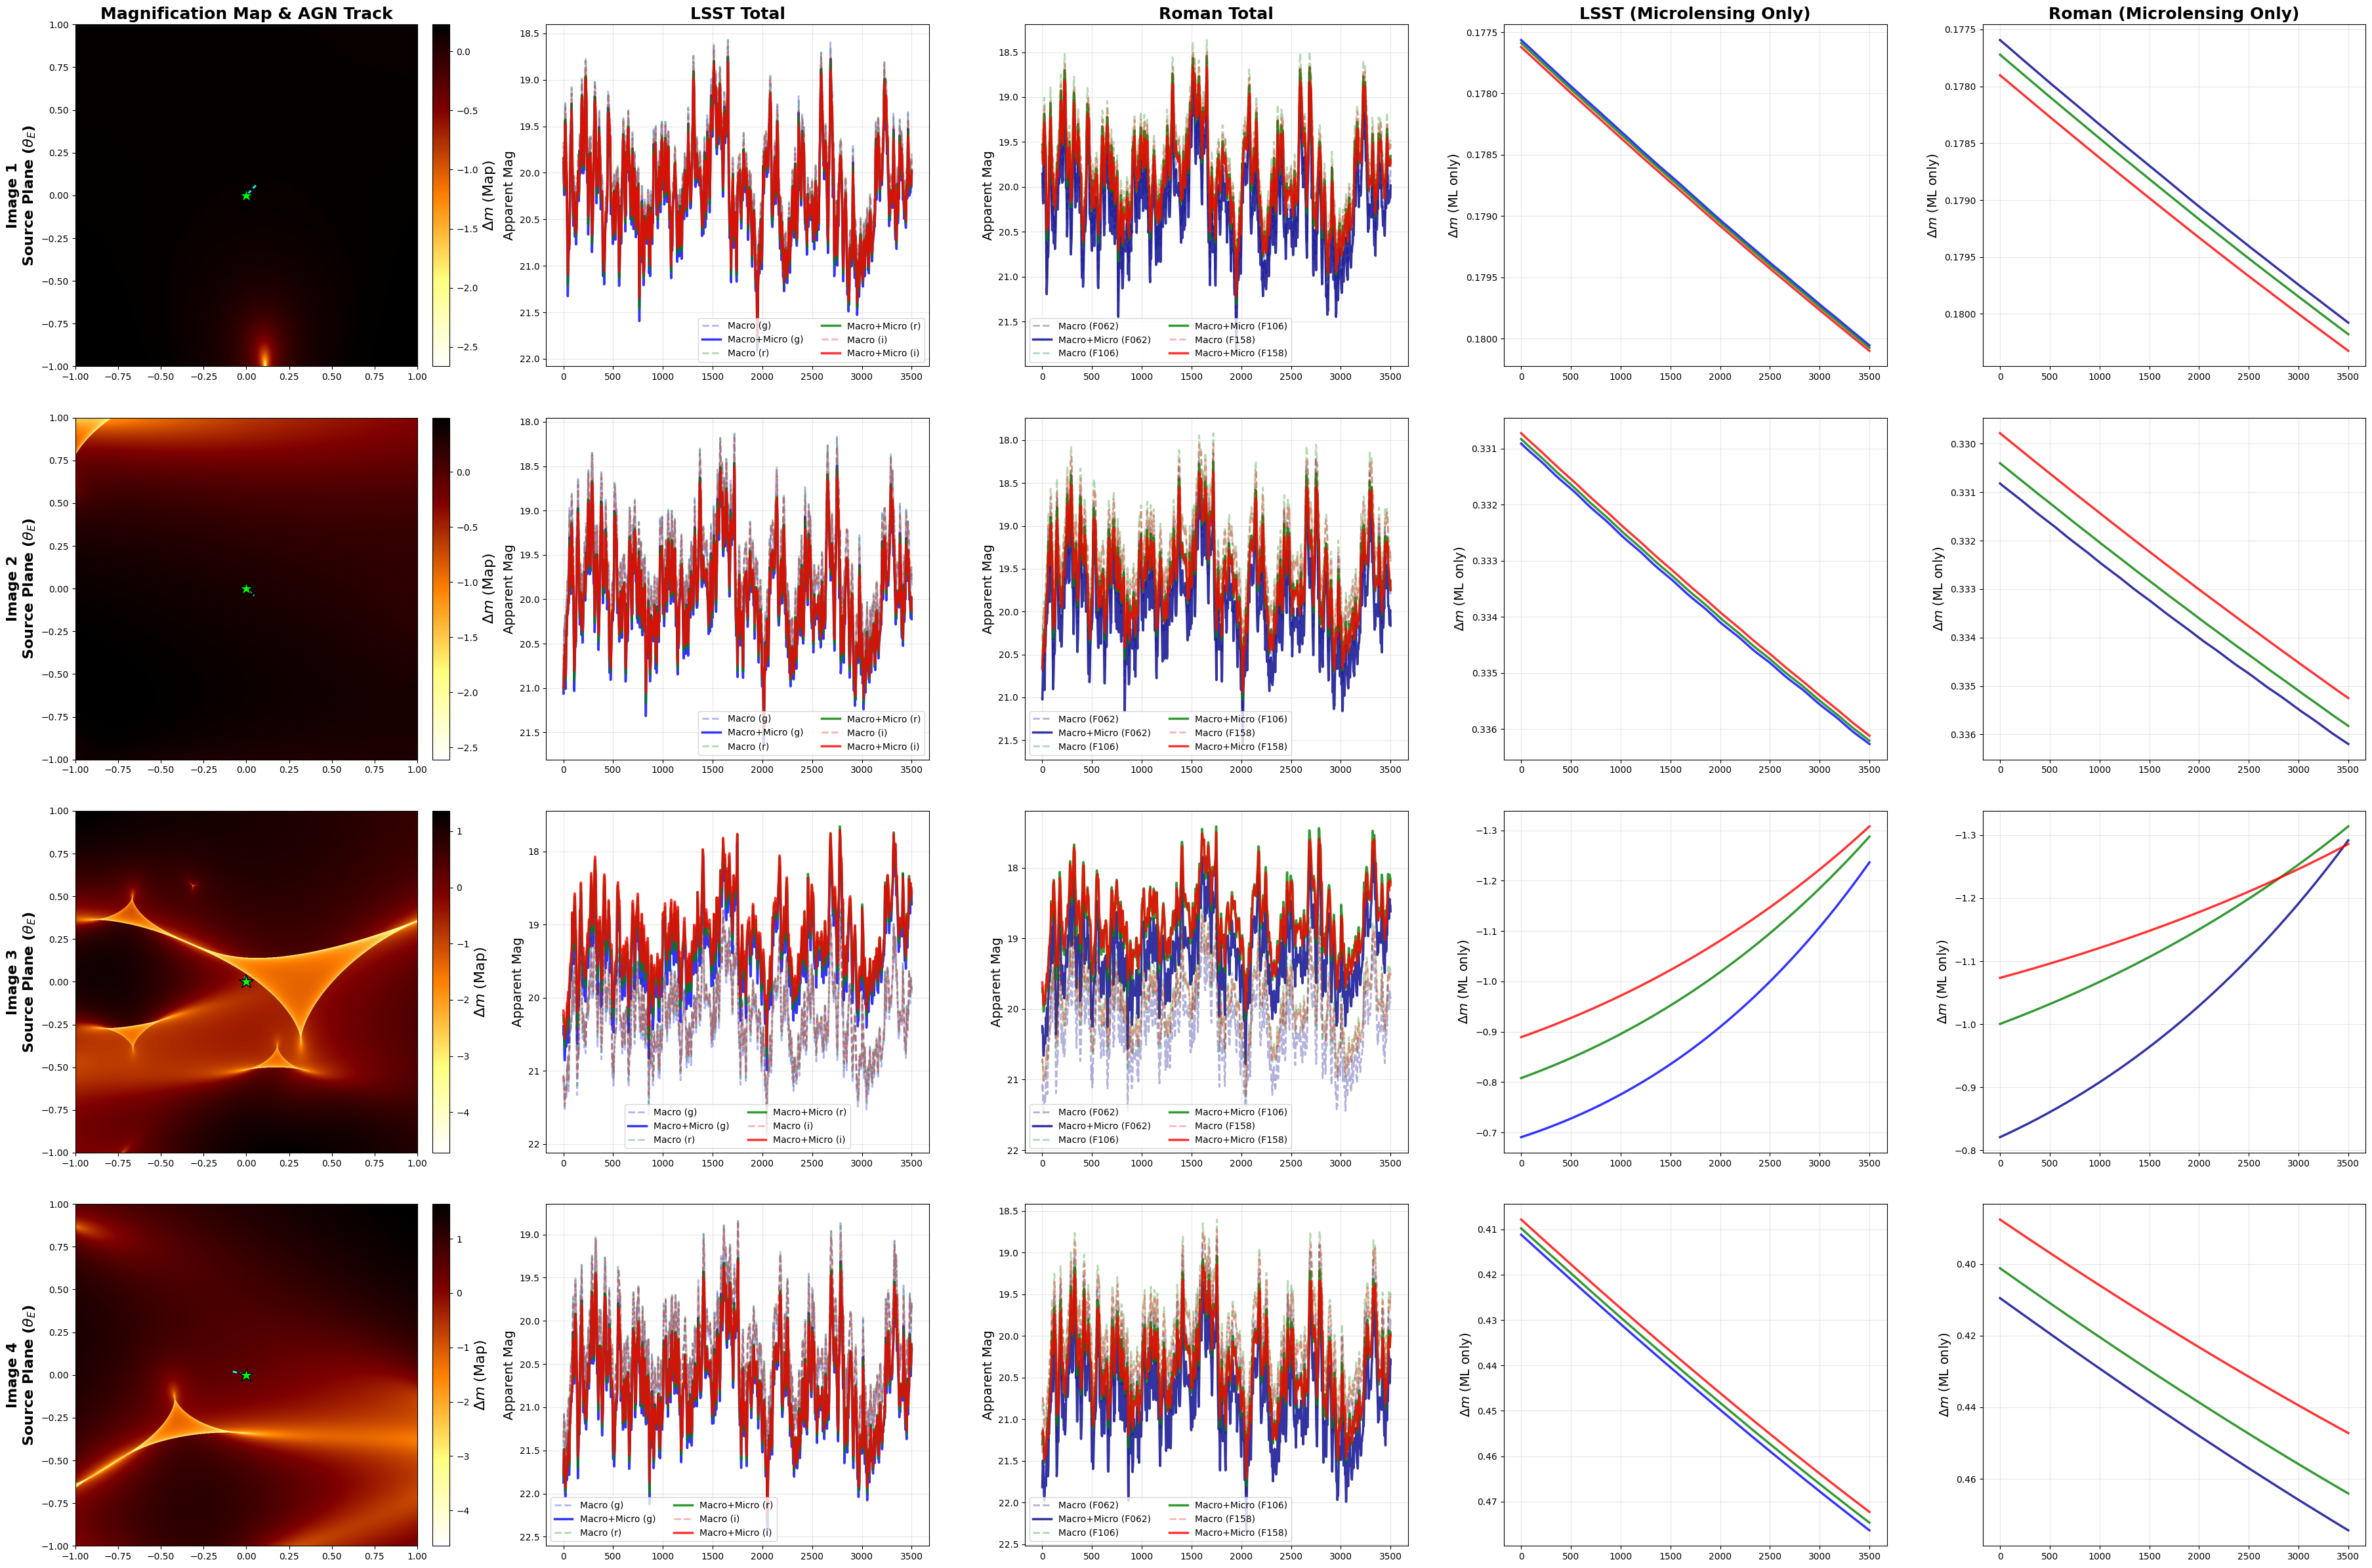

In [6]:
compare_lsst = ["g", "r", "i"]
compare_roman = ["F062", "F106", "F158"]
t_test = np.linspace(0, 3500, 3500)

theta_E_micro_arcsec, _, _ = theta_star_physical(
    z_lens=lens_class.deflector_redshift,
    z_src=lens_class.source_redshift_list[0],
    cosmo=cosmo,
    m=1.0,
)
theta_E_micro = theta_E_micro_arcsec.value

kwargs_micro = {
    "kwargs_magnification_map": {
        "theta_star": theta_E_micro,
        "half_length_x": 1 * theta_E_micro,
        "half_length_y": 1 * theta_E_micro,
        "num_pixels_x": 1000,
        "num_pixels_y": 1000,
    },
    # "point_source_morphology": "agn", # optional as it is handled by the lens class based on the source type
    "kwargs_source_morphology": {},  # optional, values are taken from the source class
}

print("Processing Multi-Band Macrolensing and Microlensing...")
lsst_macro, lsst_micro, roman_macro, roman_micro = {}, {}, {}, {}

for band in compare_lsst:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    lsst_macro[band] = lens_class.point_source_magnitude(
        band=band, time=t_test, lensed=True, microlensing=False
    )[0]
    lsst_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=t_test,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]

for band in compare_roman:
    kwargs_micro["kwargs_source_morphology"]["observing_wavelength_band"] = band
    roman_macro[band] = lens_class.point_source_magnitude(
        band=band, time=t_test, lensed=True, microlensing=False
    )[0]
    roman_micro[band] = lens_class.point_source_magnitude(
        band=band,
        time=t_test,
        lensed=True,
        microlensing=True,
        kwargs_microlensing=kwargs_micro,
    )[0]

lcm = lens_class.microlensing_model_class(source_index=0)
num_images = lens_class.image_number[0]

# %%
print("Visualizing Continuous Macrolensing + Microlensing Signatures...")

fig, axes = plt.subplots(num_images, 5, figsize=(36, 6 * num_images))
if num_images == 1:
    axes = np.atleast_2d(axes)

colors = {
    "g": "blue",
    "r": "green",
    "i": "red",
    "F062": "darkblue",
    "F106": "green",
    "F158": "red",
}

for i in range(num_images):
    ax_map, ax_lsst, ax_roman, ax_lsst_ml, ax_roman_ml = axes[i]

    # -------------------------------------------------------------
    # PANEL A: Magnification Map & Track
    # -------------------------------------------------------------
    magmap = lcm.magmaps_images[i]
    track_x, track_y = lcm.tracks[i][0]
    hl_te = magmap.half_length_x / theta_E_micro
    tx_te = (track_x / magmap.num_pixels_x) * (2 * hl_te) - hl_te
    ty_te = (track_y / magmap.num_pixels_x) * (2 * hl_te) - hl_te

    im = ax_map.imshow(
        -2.5 * np.log10(magmap.magnifications / np.abs(magmap.mu_ave)),
        origin="lower",
        cmap="afmhot_r",
        extent=[-hl_te, hl_te, -hl_te, hl_te],
    )
    ax_map.plot(tx_te, ty_te, color="cyan", lw=2, linestyle="--")
    ax_map.plot(
        tx_te[0],
        ty_te[0],
        marker="*",
        color="lime",
        markersize=16,
        markeredgecolor="black",
        zorder=10,
    )
    ax_map.set_ylabel(
        f"Image {i+1}\nSource Plane ($\\theta_E$)", fontweight="bold", fontsize=16
    )
    plt.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04).set_label(
        r"$\Delta m$ (Map)", fontsize=16
    )

    # -------------------------------------------------------------
    # PANELS B & D: LSST Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_lsst:
        c = colors.get(band, "black")
        ax_lsst.plot(
            t_test,
            lsst_macro[band][i],
            color=c,
            linestyle="--",
            lw=2,
            alpha=0.3,
            label=f"Macro ({band})",
        )
        ax_lsst.plot(
            t_test,
            lsst_micro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"Macro+Micro ({band})",
        )
        ax_lsst_ml.plot(
            t_test,
            lsst_micro[band][i] - lsst_macro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"ML Only ({band})",
        )

    ax_lsst.invert_yaxis()
    ax_lsst_ml.invert_yaxis()
    ax_lsst.set_ylabel("Apparent Mag", fontsize=14)
    ax_lsst_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_lsst.legend(fontsize=10, ncol=2)
    ax_lsst.grid(True, alpha=0.3)
    ax_lsst_ml.grid(True, alpha=0.3)

    # -------------------------------------------------------------
    # PANELS C & E: Roman Total & Micro-Only
    # -------------------------------------------------------------
    for band in compare_roman:
        c = colors.get(band, "black")
        ax_roman.plot(
            t_test,
            roman_macro[band][i],
            color=c,
            linestyle="--",
            lw=2,
            alpha=0.3,
            label=f"Macro ({band})",
        )
        ax_roman.plot(
            t_test,
            roman_micro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"Macro+Micro ({band})",
        )
        ax_roman_ml.plot(
            t_test,
            roman_micro[band][i] - roman_macro[band][i],
            color=c,
            lw=2.5,
            alpha=0.8,
            label=f"ML Only ({band})",
        )

    ax_roman.invert_yaxis()
    ax_roman_ml.invert_yaxis()
    ax_roman.set_ylabel("Apparent Mag", fontsize=14)
    ax_roman_ml.set_ylabel(r"$\Delta m$ (ML only)", fontsize=14)
    ax_roman.legend(fontsize=10, ncol=2)
    ax_roman.grid(True, alpha=0.3)
    ax_roman_ml.grid(True, alpha=0.3)

    if i == 0:
        ax_map.set_title(
            "Magnification Map & AGN Track", fontsize=18, fontweight="bold"
        )
        ax_lsst.set_title("LSST Total", fontsize=18, fontweight="bold")
        ax_roman.set_title("Roman Total", fontsize=18, fontweight="bold")
        ax_lsst_ml.set_title("LSST (Microlensing Only)", fontsize=18, fontweight="bold")
        ax_roman_ml.set_title(
            "Roman (Microlensing Only)", fontsize=18, fontweight="bold"
        )

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.15)
plt.show()

In [7]:
# Recompute magmaps
# lens_class.reset_microlensing_model_class(0)
# Reset track starting position
# lens_class.microlensing_model_class(0).reset_start_position(
#     x_start_position=0.8 * theta_E_micro, y_start_position=-0.25 * theta_E_micro
# )

# after this rerun the cell above to see how the microlensing signatures change with a different track realization